In [1]:
# =============================================================================
# PROJECT:  Causal Impact of Ad Exposure on Conversion Rate
# AUTHOR:   Francesca [Your Last Name]
# DATE:     2025
# PURPOSE:  Measure the true causal effect of ad exposure on conversions
#           using Inverse Probability Weighting (IPW) to remove selection bias.
#           Raw lift comparisons overestimate ad impact because exposed users
#           are systematically different from non-exposed users.
# DATASET:  Synthetic marketing dataset (data/synthetic_marketing_data.csv)
# =============================================================================
 
 
# -----------------------------------------------------------------------------
# PART 1 — Load and Inspect the Dataset
# -----------------------------------------------------------------------------
 
import pandas as pd
 
df = pd.read_csv('data/synthetic_marketing_data.csv')
 
print(f"Dataset loaded successfully: {df.shape[0]} rows found.")
display(df.head())
 
# Expected columns:
# - age: user age
# - past_purchases: number of previous purchases
# - device: device type (e.g., 'mobile', 'desktop')
# - is_exposed_to_ad: 1 = saw the ad, 0 = did not see the ad (treatment)
# - converted: 1 = converted, 0 = did not convert (outcome)

Dataset loaded successfully: 50000 rows found.


,age,device,past_purchases,is_exposed_to_ad,converted
0,39.967142,mobile,3,0,0
1,33.617357,mobile,3,0,0
2,41.476885,desktop,2,0,0
3,50.230299,desktop,1,0,0
4,32.658466,mobile,2,0,0


In [2]:
# PART 2 — Propensity Score Estimation
# -----------------------------------------------------------------------------
# The Propensity Score (PS) is the probability that a user was exposed to the
# ad, given their observable characteristics (age, device, past purchases).
#
# Why do we need this?
# Users who see ads are not randomly selected — they tend to be younger,
# more mobile-heavy, and more engaged. If we compare raw conversion rates,
# we are partly measuring user quality, not ad effectiveness.
#
# By modeling the likelihood of exposure, we can re-weight the data so that
# both groups look statistically comparable — as if exposure were randomized.
# -----------------------------------------------------------------------------
 
from sklearn.linear_model import LogisticRegression
 
# Encode categorical variable 'device' as binary dummy (mobile = 1)
df_model = pd.get_dummies(df, columns=['device'], drop_first=True)
 
# Features used to predict ad exposure (confounders)
X = df_model[['age', 'past_purchases', 'device_mobile']]
 
# Treatment variable: 1 = exposed to ad, 0 = not exposed
T = df_model['is_exposed_to_ad']
 
# Train logistic regression to estimate propensity scores
lr = LogisticRegression()
lr.fit(X, T)
 
# Save propensity score: probability of being exposed to the ad
df_model['ps'] = lr.predict_proba(X)[:, 1]
 
print("Propensity Scores calculated.")
print("Each score represents the estimated probability of seeing the ad,")
print("based on user age, device type, and past purchase behaviour.\n")
 
# Sanity check on PS distribution — extreme values cause unstable weights
print(df_model['ps'].describe())

Propensity Scores calculated.
Each score represents the estimated probability of seeing the ad,
based on user age, device type, and past purchase behaviour.

count    50000.000000
mean         0.409500
std          0.193931
min          0.028949
25%          0.236220
50%          0.413451
75%          0.569087
max          0.885172
Name: ps, dtype: float64


In [3]:
# PART 3 — Inverse Probability Weighting (IPW)
# -----------------------------------------------------------------------------
# IPW re-weights each observation so that both exposed and control groups
# look like a representative sample of the full population.
#
# - Exposed users who were unlikely to see the ad → upweighted (weight = 1/PS)
# - Control users who were likely to see the ad   → upweighted (weight = 1/(1-PS))
#
# This creates a "pseudo-population" where treatment assignment is independent
# of observed confounders, allowing causal comparison.
# -----------------------------------------------------------------------------
 
# Calculate IPW weights
df_model['weight'] = df_model.apply(
    lambda x: 1 / x['ps'] if x['is_exposed_to_ad'] == 1 else 1 / (1 - x['ps']),
    axis=1
)
 
# Check for extreme weights that could destabilize results
print(f"Observations with weight > 10 (potential instability): {(df_model['weight'] > 10).sum()}")
 
# Weighted Conversion Rate: applies IPW weights to recover causal estimate
def get_weighted_cr(data, group_val):
    """
    Calculates the IPW-weighted conversion rate for a given treatment group.
    
    Parameters:
        data (DataFrame): model dataset with 'weight' and 'converted' columns
        group_val (int): 1 for treated (exposed), 0 for control (not exposed)
    
    Returns:
        float: weighted conversion rate
    """
    subset = data[data['is_exposed_to_ad'] == group_val]
    return (subset['converted'] * subset['weight']).sum() / subset['weight'].sum()
 
 
cr_control_causal   = get_weighted_cr(df_model, 0)
cr_treatment_causal = get_weighted_cr(df_model, 1)
causal_lift         = cr_treatment_causal - cr_control_causal
 
print("\n--- CAUSAL RESULTS (IPW-Adjusted) ---")
print(f"Conversion Rate — Control (No Ad):  {cr_control_causal * 100:.2f}%")
print(f"Conversion Rate — Treated (Ad):     {cr_treatment_causal * 100:.2f}%")
print(f"True Causal Lift:                   {causal_lift * 100:.2f}%")
 

Observations with weight > 10 (potential instability): 102

--- CAUSAL RESULTS (IPW-Adjusted) ---
Conversion Rate — Control (No Ad):  11.28%
Conversion Rate — Treated (Ad):     16.45%
True Causal Lift:                   5.17%


In [7]:
# PART 4 — Raw (Unadjusted) Lift for Comparison
# -----------------------------------------------------------------------------
# This is the naive lift a junior analyst would report.
# It does NOT account for the fact that exposed users are inherently different.
# Comparing raw rates conflates ad effectiveness with user-level selection bias.
# -----------------------------------------------------------------------------
 
raw_cr   = df.groupby('is_exposed_to_ad')['converted'].mean()
raw_lift = (raw_cr[1] - raw_cr[0]) * 100

print(f"Raw CR — Control: {raw_cr[0]*100:.2f}%")
print(f"Raw CR — Exposed: {raw_cr[1]*100:.2f}%")
print(f"\n--- RAW RESULTS (Unadjusted — Biased) ---")
print(f"Raw Lift (no bias correction): {raw_lift:.2f}%")
print(f"\nBias estimate (raw - causal): {raw_lift - causal_lift * 100:.2f} percentage points")
print("→ This gap represents how much of the observed uplift was driven by")
print("  user characteristics, not actual ad exposure.\n")

Raw CR — Control: 10.78%
Raw CR — Exposed: 16.83%

--- RAW RESULTS (Unadjusted — Biased) ---
Raw Lift (no bias correction): 6.05%

Bias estimate (raw - causal): 0.89 percentage points
→ This gap represents how much of the observed uplift was driven by
  user characteristics, not actual ad exposure.



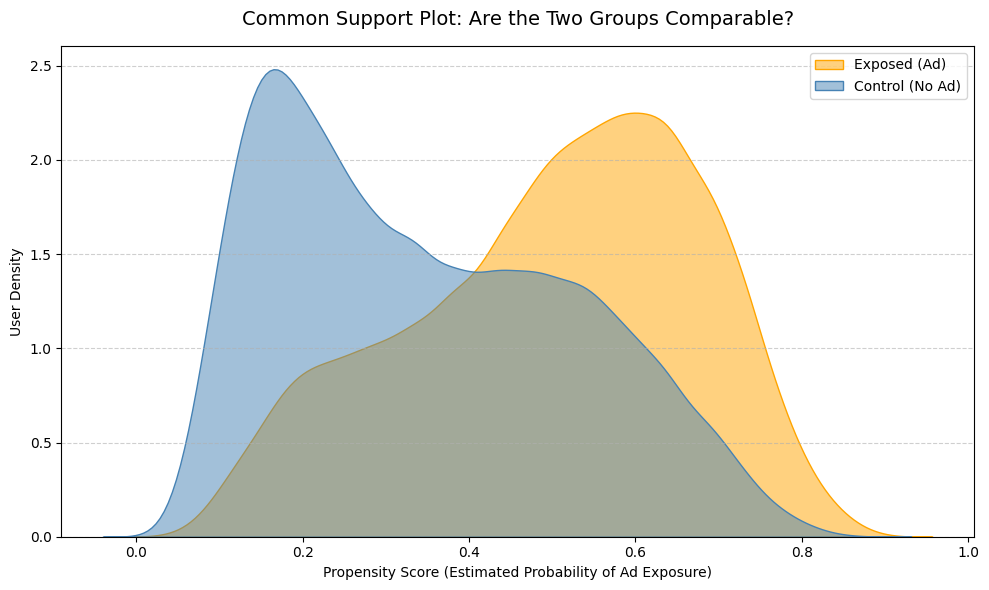

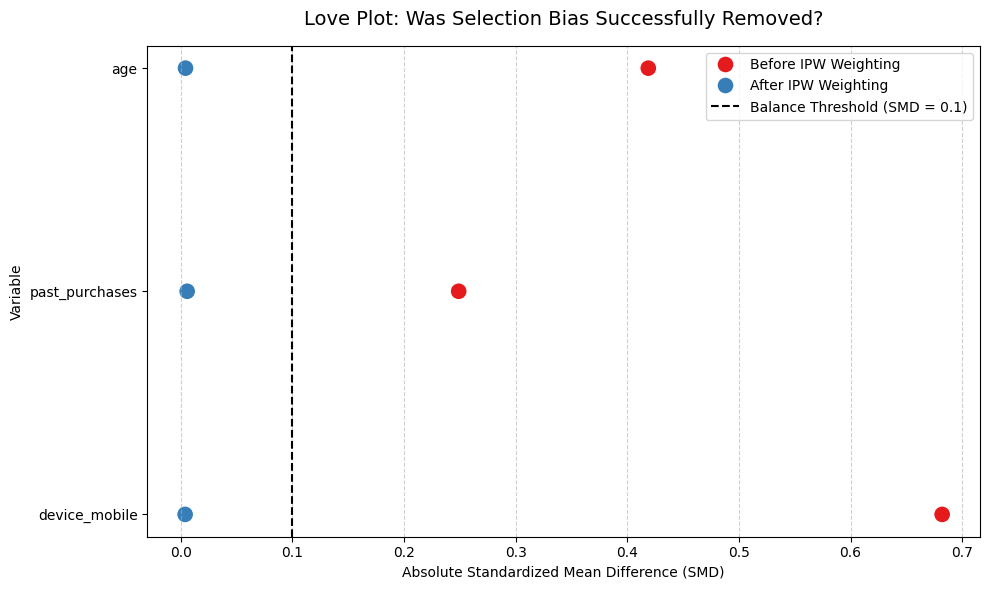

In [5]:
# PART 5 — Visualisations
# -----------------------------------------------------------------------------
 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
 
# --- PLOT 1: Common Support ---
# Checks whether both groups share a similar range of propensity scores.
# If exposed and control users have completely different PS distributions,
# the comparison breaks down — we would be comparing incomparable groups.
# Good overlap = reliable causal estimate.
 
plt.figure(figsize=(10, 6))
 
sns.kdeplot(
    data=df_model[df_model['is_exposed_to_ad'] == 1],
    x='ps', fill=True, label='Exposed (Ad)', alpha=0.5, color='orange'
)
sns.kdeplot(
    data=df_model[df_model['is_exposed_to_ad'] == 0],
    x='ps', fill=True, label='Control (No Ad)', alpha=0.5, color='steelblue'
)
 
plt.title('Common Support Plot: Are the Two Groups Comparable?', fontsize=14, pad=15)
plt.xlabel('Propensity Score (Estimated Probability of Ad Exposure)')
plt.ylabel('User Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
 
# Interpretation: Substantial overlap between curves confirms that both groups
# contain users with similar characteristics — IPW comparison is valid.
 
 
# --- PLOT 2: Balance Plot (Love Plot) ---
# The Love Plot shows Standardized Mean Differences (SMD) for each covariate,
# before and after IPW weighting.
#
# SMD measures how different the two groups are on each feature.
# A threshold of 0.1 is the conventional benchmark for "good balance".
# After IPW, all SMDs should fall below 0.1 — confirming bias was removed.
 
def calculate_smd(df, treatment_col, covariates, weight_col=None):
    """
    Calculates absolute Standardized Mean Difference (SMD) for each covariate.
    Used to assess covariate balance between treatment and control groups.
 
    Parameters:
        df (DataFrame): dataset
        treatment_col (str): binary treatment indicator column
        covariates (list): list of covariate column names
        weight_col (str, optional): column of IPW weights; if None, uses raw means
 
    Returns:
        list: absolute SMD values for each covariate
    """
    smds = []
    for col in covariates:
        t1 = df[df[treatment_col] == 1]
        t0 = df[df[treatment_col] == 0]
 
        if weight_col:
            m1 = np.average(t1[col], weights=t1[weight_col])
            m0 = np.average(t0[col], weights=t0[weight_col])
            v1 = np.average((t1[col] - m1) ** 2, weights=t1[weight_col])
            v0 = np.average((t0[col] - m0) ** 2, weights=t0[weight_col])
        else:
            m1, m0 = t1[col].mean(), t0[col].mean()
            v1, v0 = t1[col].var(), t0[col].var()
 
        smd = (m1 - m0) / np.sqrt((v1 + v0) / 2)
        smds.append(abs(smd))
 
    return smds
 
 
covariates = ['age', 'past_purchases', 'device_mobile']
 
smd_raw = calculate_smd(df_model, 'is_exposed_to_ad', covariates)
smd_adj = calculate_smd(df_model, 'is_exposed_to_ad', covariates, weight_col='weight')
 
plot_data = pd.DataFrame({
    'Variable': covariates * 2,
    'SMD':      smd_raw + smd_adj,
    'Type':     ['Before IPW Weighting'] * 3 + ['After IPW Weighting'] * 3
})
 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x='SMD', y='Variable',
    hue='Type', s=150, palette='Set1'
)
plt.axvline(x=0.1, color='black', linestyle='--', label='Balance Threshold (SMD = 0.1)')
plt.title('Love Plot: Was Selection Bias Successfully Removed?', fontsize=14, pad=15)
plt.xlabel('Absolute Standardized Mean Difference (SMD)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
 
# Interpretation: Points to the LEFT of the dashed line (SMD < 0.1) indicate
# balanced covariates. After IPW weighting, all variables should cross the threshold,
# confirming that the causal comparison is no longer confounded by user characteristics.
 

In [6]:
# SUMMARY — Business Interpretation
# -----------------------------------------------------------------------------
print("=" * 60)
print("BUSINESS SUMMARY")
print("=" * 60)
print(f"Raw (unadjusted) lift:      {raw_lift:.2f}%")
print(f"Causal (IPW-adjusted) lift: {causal_lift * 100:.2f}%")
print(f"Overestimation bias:        {raw_lift - causal_lift * 100:.2f} pp")
print()
print("The naive comparison overstates ad effectiveness because")
print("exposed users were already more likely to convert (younger,")
print("more purchases, more mobile). After removing this selection")
print("bias via IPW, the true incremental impact of the ad is")
print(f"{causal_lift * 100:.2f}% — a more reliable figure for budget decisions.")
print("=" * 60)
 

BUSINESS SUMMARY
Raw (unadjusted) lift:      6.05%
Causal (IPW-adjusted) lift: 5.17%
Overestimation bias:        0.89 pp

The naive comparison overstates ad effectiveness because
exposed users were already more likely to convert (younger,
more purchases, more mobile). After removing this selection
bias via IPW, the true incremental impact of the ad is
5.17% — a more reliable figure for budget decisions.
